In [26]:
import qiskit as qc
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.synthesis import SuzukiTrotter
import numpy as np
from qiskit.primitives import StatevectorEstimator
import matplotlib.pyplot as plt


In [27]:
def hamiltonian1(L, J):
    """
    Docstring for hamiltonian
    
    :param X: X pauli op
    (X, 0, t)
    :param Y: Y pauli op
    :param Z: Z pauli op
    """
    ham_list = []

    for i in range (int(L)-1):
        ham_list.append(("XX", [i, i+1], -1)) # XX bc Xi and X i+1
        ham_list.append(("YY", [i, i+1], -1))
        ham_list.append(("ZZ", [i, i+1], -Jz))

    H =  SparsePauliOp.from_sparse_list(ham_list, num_qubits=L)

    return H


Jz = 1.1 #can vary

a = 4 #THIS IS L

def initialise(Jz, a):
    """ 
    decides L and the initial state to use depending on the value of Jz
    Returns: L, initial states
    """
    if  Jz > 1:
        L = a
        # all |0> ^tensor L
        psi_0 = Statevector.from_label("0"*L)
        # all |1> ^tensor L
        psi_1 = Statevector.from_label("1"*L)

        return L, [psi_0, psi_1]
    
    elif Jz < -1:
        L = a
        
        alternating = "".join(["10"[(i % 2)] for i in range(L)])
        psi_10 = Statevector.from_label(alternating)
        
        return L, [psi_10]
    
    else:
        raise ValueError("Jz must be >1 or < -1")

L, initial_states = initialise(Jz, a) #L HERE IS WHAT THE TENSOR NUMBER IS

H = hamiltonian1(L, Jz)

print(H)

SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[-1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j,
 -1. +0.j, -1.1+0.j])


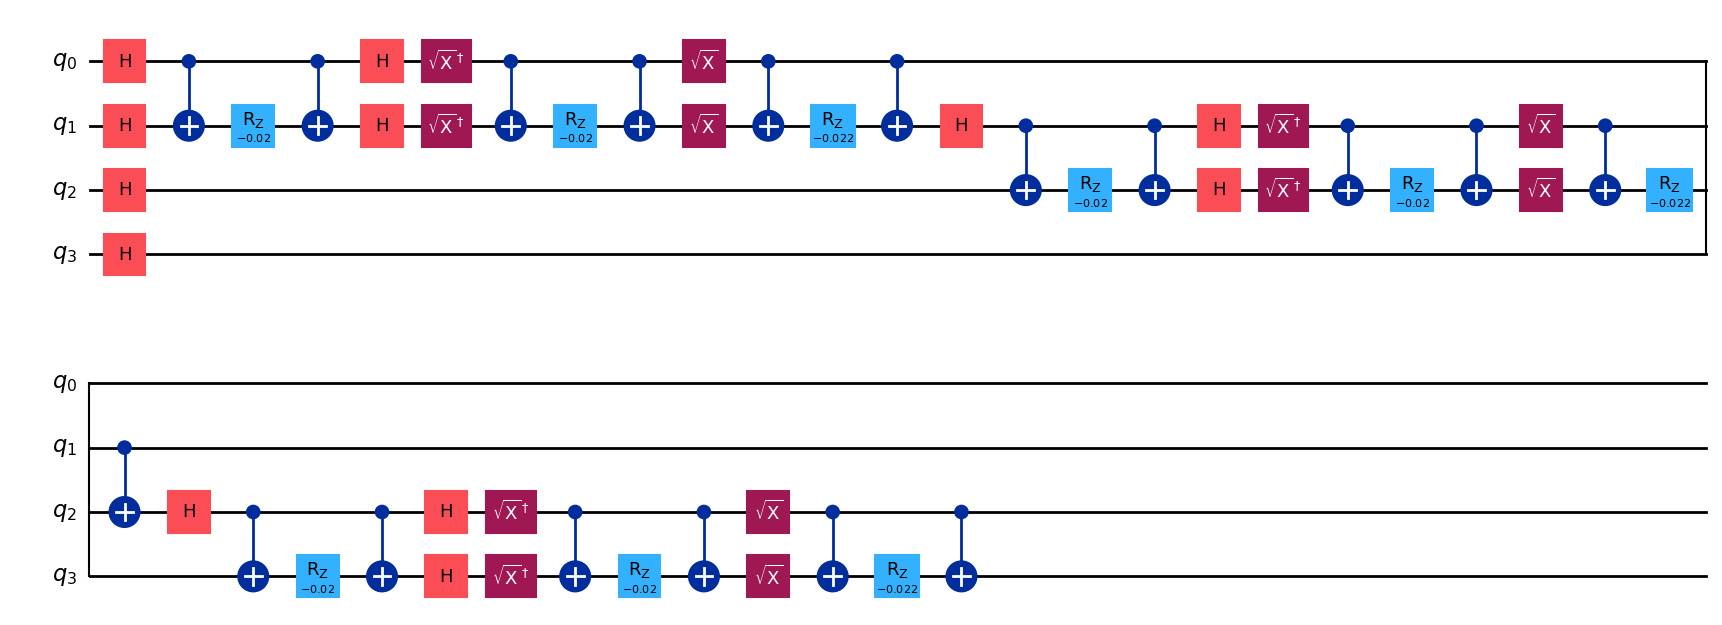

In [28]:
dt = 1e-2
gate = PauliEvolutionGate(dt * hamiltonian1(L,1.1))
st = SuzukiTrotter(order=1, reps=1)
circ = st.synthesize(gate)
circ.decompose().draw("mpl")

In [29]:
def function(coord,i,dt,ttot,order,L,Jz):
    ''' 
    coord = 'X' or 'Y' or 'Z'
    i is ith qubit
    '''

    gate = PauliEvolutionGate(dt * hamiltonian1(L,Jz))
     
    # Define reps
    reps = int(round(ttot/dt))

    # Define the 'Estimator' primitive used to measure/estimate expectation values of observables
    estimator = StatevectorEstimator()

    # Define the observables we wish to estimate
    coordstring = (i-1)*'I' + coord + (L-i)*'I'
    obs = SparsePauliOp([coordstring],coeffs=[1])#num_qubits=L)
    # Initialise circuit
    #quantum circuit (printed)
    qc = QuantumCircuit(int(L)) 

    #FFIX THIS
    L, psi = initialise(Jz,L) #chosen an initial state
    psi = psi[0]

    qc.initialize(psi.data, range(L)) #initialise state

    #apply rotation
    middle = L //2 #picks L/2 int value
    qc.ry(np.pi/2, middle) #rotation here is into x-y plane


    # Define a single Suzuki-Trotter timestep
    st = SuzukiTrotter(order=order, reps=reps)
    circ = st.synthesize(evolution=gate)

    # Prepare an empty list to store data and run a loop over timesteps
    results = []

    for t in range(reps):
        qc.append(circ, list(range(L))) # to apply the circuit to all qubits of qc
        pub = (qc, [obs])
        result = estimator.run(pubs=[pub]).result()
        results.append(result[0].data.evs[0])
        

    return results

In [30]:
#SuzukiTrotter?
hamiltonian = SparsePauliOp(
[
"XX",
"YY",
"ZZ",
"ZI",
"IZ",
],
coeffs=[
1 + 0.0j,
1 + 0.0j,
1 + 0.0j,
1 + 0.0j,
1 + 0.0j,
],
)
PauliEvolutionGate(1e-2 * hamiltonian)


Instruction(name='PauliEvolution', num_qubits=2, num_clbits=0, params=[1.0])

ValueError: x and y must have same first dimension, but have shapes (250,) and (2,)

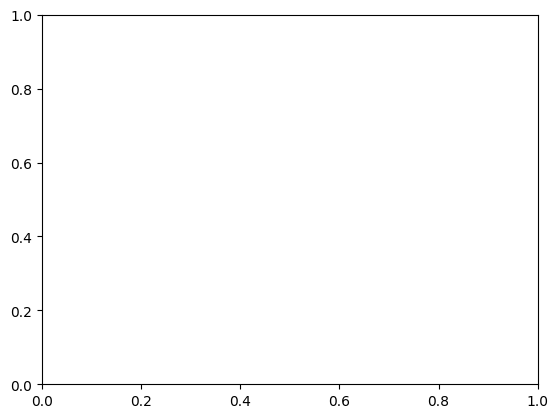

In [31]:
test1 = function('X',2,1e-2,0.02,1,4,1.1) #coord,i,dt,ttot,order,L,Jz
tlist = [0.1 * t for t in range(250)]
plt.plot(tlist, test1, '--', label = 'Trotter Circuit for X')
plt.ylabel(r'$\langle X_2(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()